***

# **BLS Visualizations**

***

In [1]:
# Packages

import plotly

# General
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import re
from datetime import date
import math
import seaborn as sns

# Plotting
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

In [10]:
# function to get unique values
def unique(list1):
 
    # initialize a null list
    unique_list = []
 
    # traverse for all elements
    for x in list1:
        # check if exists in unique_list or not
        if x not in unique_list:
            unique_list.append(x)
    return unique_list

In [2]:
# Define user
user = os.getlogin()
path_users = os.path.join('C:\\Users', user)

## Set file paths

path_git = os.path.join(path_users, 'Documents', 'Python Projects', 'Regional-Monitoring', 'Indicator_Gen')

path_config0 = os.path.join(path_git, 'config')
path_config  = os.path.join(path_git, 'Python Code', 'BLS', 'config')

In [3]:
# Impoting data

df_jobs = pd.read_csv(os.path.join(path_config, 'Jobs_1_MSA_BLS_SMU.csv'))

df_jobs.head(3)

,date,MSA,Variable,Value
0,2000-01-01,"Austin-Round Rock-Georgetown, TX Metro Area",Government,138700.0
1,2000-01-01,"Austin-Round Rock-Georgetown, TX Metro Area",Total Private,518700.0
2,2000-01-01,"Charlotte-Concord-Gastonia, NC-SC Metro Area",Government,109500.0


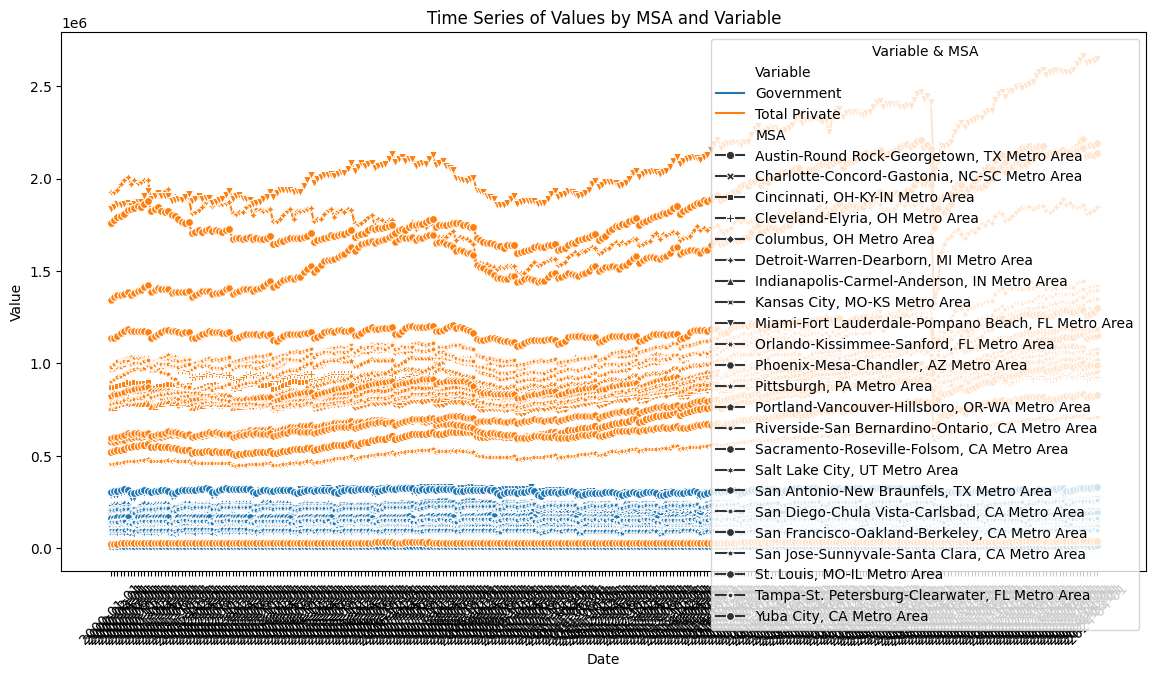

In [14]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_jobs, x='date', y='Value', hue='Variable', style='MSA', markers=True, dashes=False)
plt.title('Time Series of Values by MSA and Variable')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(title='Variable & MSA')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Plotting number of jobs by MSA and Variable.

fig = px.line(df_jobs, x='date', y="Value", color='MSA', line_group = 'Variable', line_dash='Variable')
fig.show()

In [9]:
# Subset just using Total Private

fig = px.line(df_jobs[df_jobs['Variable']== 'Total Private'], x='date', y="Value", color='MSA', line_group = 'Variable')
fig.show()

In [14]:
# Plotting setup

loop_vars = False
by_msa = False
by_var = False
x = 'date'
y = 'Value'
color = 'MSA'
line_dash = 'Variable'
variable = 'Variable'
markers = True
plot_title = 'Total Jobs per Industry by Peer MSAs'
plot_name = 'Industry by Peers'
export = False

def plot_lines(
    df,
    loop_vars=False, by_msa=False, msa_column='MSA', variable='Variable', value_column='Value',
    x='date', y='Value',
    color='MSA', line_dash='MSA', markers=True,
    plot_title='Line Plot', plot_name='line_plot',
    export=False, path_plots='.', indicator_name='indicator'
):
    if by_msa:
        df = df[df[msa_column] != 'All']
    else:
        df = df[df[msa_column] == 'All'].drop(msa_column, axis=1)

    if loop_vars:
        unique_vars = df[variable].unique()
        for var in unique_vars:
            df2 = df[df[variable] == var]
            fig = px.line(df2, x=x, y=y, color=color, line_dash=line_dash, markers=markers)
            fig.update_layout(title=f'{plot_title} - {var}')
            # if export:
            #     fig.write_html(os.path.join(path_plots, f'{indicator_name}_{plot_name}_{var}_line.html'))
            fig.update_layout(autosize=False, width=1050, height=450)
            fig.show()
    else:
        fig = px.line(df, x=x, y=y, color=color, line_dash=line_dash, markers=markers)
        fig.update_layout(title=plot_title)
        # if export:
        #     fig.write_html(os.path.join(path_plots, f'{indicator_name}_{plot_name}_line.html'))
        fig.update_layout(autosize=False, width=1050, height=450)
        fig.show()

plot_lines(df=df_jobs, 
           loop_vars=True,
            by_msa=True,
            msa_column='MSA',
            variable='Variable',
            value_column='Value',
              x='date', y='Value',
                color='MSA',
                      line_dash='MSA',
                        markers=True,
                          plot_title='Time Series Plot',
                            plot_name='time_series_plot',
                              export=False)

In [17]:
pip install statsmodels

     ---------------------------------------- 0.0/60.6 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.6 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.6 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 60.6/60.6 kB 541.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.4/9.8 MB 12.8 MB/s eta 0:00:01
   ------ --------------------------------- 1.5/9.8 MB 16.0 MB/s eta 0:00:01
   ------ --------------------------------- 1.7/9.8 MB 11.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.8/9.8 MB 20.2 MB/s eta 0:00:01
   ---------------------- ----------------- 5.6/9.8 MB 23.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.8 MB 25.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.8/9.8 MB 25.5 MB/s eta 0:00:01
   ---------------------------------------  9.8/9.8 MB 26.2 MB/s eta 0:00:01
   -------

In [22]:
import statsmodels.api as sm
from statsmodels.tsa.arima_model import ARIMA


mod = sm.tsa.arima.ARIMA(np.asarray(df_jobs['Value']), order=(1, 1, 0))
res = mod.fit()
print(res.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                13432
Model:                 ARIMA(1, 1, 0)   Log Likelihood             -193615.869
Date:                Thu, 13 Jun 2024   AIC                         387235.739
Time:                        15:51:24   BIC                         387250.749
Sample:                             0   HQIC                        387240.746
                              - 13432                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8927      0.003   -275.925      0.000      -0.899      -0.886
sigma2      1.944e+11   8.09e-16    2.4e+26      0.000    1.94e+11    1.94e+11
Ljung-Box (L1) (Q):                   1.06   Jarque-

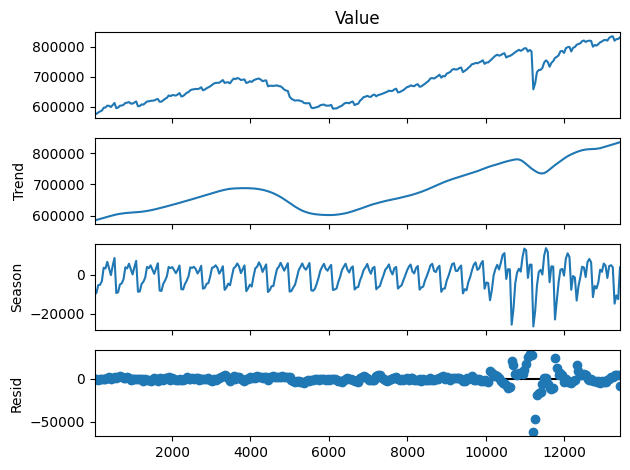

In [38]:
from statsmodels.tsa.seasonal import STL

df_jobs_sac = df_jobs.loc[df_jobs['MSA'] == 'Sacramento-Roseville-Folsom, CA Metro Area']

df_jobs_sac_priv = df_jobs_sac[df_jobs_sac['Variable'] == 'Total Private']

res = STL(df_jobs_sac_priv['Value'], period=12).fit()
res.plot()
plt.show()